In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ── Load Data ─────────────────────────────────────────────────────────────────
dataset = pd.read_csv("/content/sample_data/classData.csv")
X = dataset.iloc[:, 4:]
y = dataset.iloc[:, 0:4]

# X_train/X_test are pandas DataFrames here ✅
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ── Dataset Class ─────────────────────────────────────────────────────────────
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)  # .values works ✅
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CustomDataset(X_train, y_train)
test_dataset  = CustomDataset(X_test,  y_test)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

# ── Model ─────────────────────────────────────────────────────────────────────
class FaultANN(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.network(x)

model = FaultANN(train_dataset.X.shape[1])

# ── Training ──────────────────────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    model.train()
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs    = model(X_batch)
        loss       = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/100]  Loss: {epoch_loss/len(train_loader):.4f}")

Epoch [10/100]  Loss: 0.1813
Epoch [20/100]  Loss: 0.1245
Epoch [30/100]  Loss: 0.1035
Epoch [40/100]  Loss: 0.0958
Epoch [50/100]  Loss: 0.0927
Epoch [60/100]  Loss: 0.0822
Epoch [70/100]  Loss: 0.0744
Epoch [80/100]  Loss: 0.0781
Epoch [90/100]  Loss: 0.0778
Epoch [100/100]  Loss: 0.0729


In [ ]:
dataset.head()

,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983


In [ ]:
# ── Evaluation ────────────────────────────────────────────────────────────────
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs     = model(X_batch)
        probs       = torch.sigmoid(outputs)
        predictions = (probs > 0.5).int()
        all_preds.append(predictions)
        all_labels.append(y_batch.int())

all_preds  = torch.cat(all_preds,  dim=0)
all_labels = torch.cat(all_labels, dim=0)

# ── Accuracy Metrics ──────────────────────────────────────────────────────────
# 1. Exact Match Accuracy (all 4 labels must match)
exact_match = (all_preds == all_labels).all(dim=1).float().mean().item()

# 2. Per-label Accuracy (each output neuron individually)
per_label   = (all_preds == all_labels).float().mean(dim=0)
labels      = ['G', 'C', 'B', 'A']

print(f"Exact Match Accuracy : {exact_match * 100:.2f}%")
print()
print("Per-Label Accuracy:")
for name, acc in zip(labels, per_label):
    print(f"  {name} : {acc * 100:.2f}%")

Exact Match Accuracy : 86.33%

Per-Label Accuracy:
  G : 87.79%
  C : 99.36%
  B : 99.30%
  A : 99.05%


In [ ]:
from sklearn.metrics import precision_score, f1_score, classification_report

# Convert tensors to numpy
y_true = all_labels.numpy()
y_pred = all_preds.numpy()

labels = ['G', 'C', 'B', 'A']

# ── Precision ─────────────────────────────────────────────────────────────────
precision = precision_score(y_true, y_pred, average=None, zero_division=0)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)

# ── F1 Score ──────────────────────────────────────────────────────────────────
f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

# ── Per-Label Results ─────────────────────────────────────────────────────────
print(f"{'Label':<10} {'Precision':>10} {'F1 Score':>10}")
print("-" * 32)
for name, p, f in zip(labels, precision, f1):
    print(f"{name:<10} {p*100:>9.2f}% {f*100:>9.2f}%")
print("-" * 32)
print(f"{'Macro Avg':<10} {precision_macro*100:>9.2f}% {f1_macro*100:>9.2f}%")

# ── Full Report ───────────────────────────────────────────────────────────────
print("\nFull Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

Label       Precision   F1 Score
--------------------------------
G              83.22%     86.69%
C              99.02%     99.18%
B              98.95%     99.35%
A             100.00%     99.15%
--------------------------------
Macro Avg      95.30%     96.09%

Full Classification Report:
              precision    recall  f1-score   support

           G       0.83      0.90      0.87       691
           C       0.99      0.99      0.99       611
           B       0.99      1.00      0.99       849
           A       1.00      0.98      0.99       890

   micro avg       0.95      0.97      0.96      3041
   macro avg       0.95      0.97      0.96      3041
weighted avg       0.96      0.97      0.96      3041
 samples avg       0.67      0.68      0.67      3041



In [ ]:
# ── Fault Type Mapping ────────────────────────────────────────────────────────
fault_map = {
    (0, 0, 0, 0): "No Fault",
    (1, 0, 0, 1): "LG Fault   (Phase A to Ground)",
    (0, 0, 1, 1): "LL Fault   (Phase A to Phase B)",
    (1, 0, 1, 1): "LLG Fault  (Phase A, B to Ground)",
    (0, 1, 1, 1): "LLL Fault  (All Three Phases)",
    (1, 1, 1, 1): "LLLG Fault (Three Phase Symmetrical)",
}

# ── Input — enter each value separately ───────────────────────────────────────
print("Enter the 6 input values one by one:")
Ia = float(input("  Ia: "))
Ib = float(input("  Ib: "))
Ic = float(input("  Ic: "))
Va = float(input("  Va: "))
Vb = float(input("  Vb: "))
Vc = float(input("  Vc: "))

values = [Ia, Ib, Ic, Va, Vb, Vc]

# ── Predict ───────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    x      = torch.tensor(values, dtype=torch.float32).unsqueeze(0)  # shape [1, 6] ✅
    output = model(x)
    probs  = torch.sigmoid(output).squeeze()
    pred   = tuple((probs > 0.5).int().tolist())

# ── Output ────────────────────────────────────────────────────────────────────
fault = fault_map.get(pred, "Unknown Fault Pattern")

print("\n─────────────────────────────────────────")
print(f"  Input      : Ia={Ia}, Ib={Ib}, Ic={Ic}, Va={Va}, Vb={Vb}, Vc={Vc}")
print(f"  Output     : G={pred[0]}  C={pred[1]}  B={pred[2]}  A={pred[3]}")
print(f"  Fault Type : {fault}")
print(f"  Confidence : G={probs[0]:.2f}  C={probs[1]:.2f}  B={probs[2]:.2f}  A={probs[3]:.2f}")
print("─────────────────────────────────────────")

Enter the 6 input values one by one:
  Ia: -151.29
  Ib: -9.677452
  Ic: 85.800162
  Va: 0.400750
  Vb: -0.132935
  Vc: -0.267815

─────────────────────────────────────────
  Input      : Ia=-151.29, Ib=-9.677452, Ic=85.800162, Va=0.40075, Vb=-0.132935, Vc=-0.267815
  Output     : G=0  C=1  B=1  A=1
  Fault Type : LLL Fault  (All Three Phases)
  Confidence : G=0.09  C=0.78  B=0.58  A=0.79
─────────────────────────────────────────


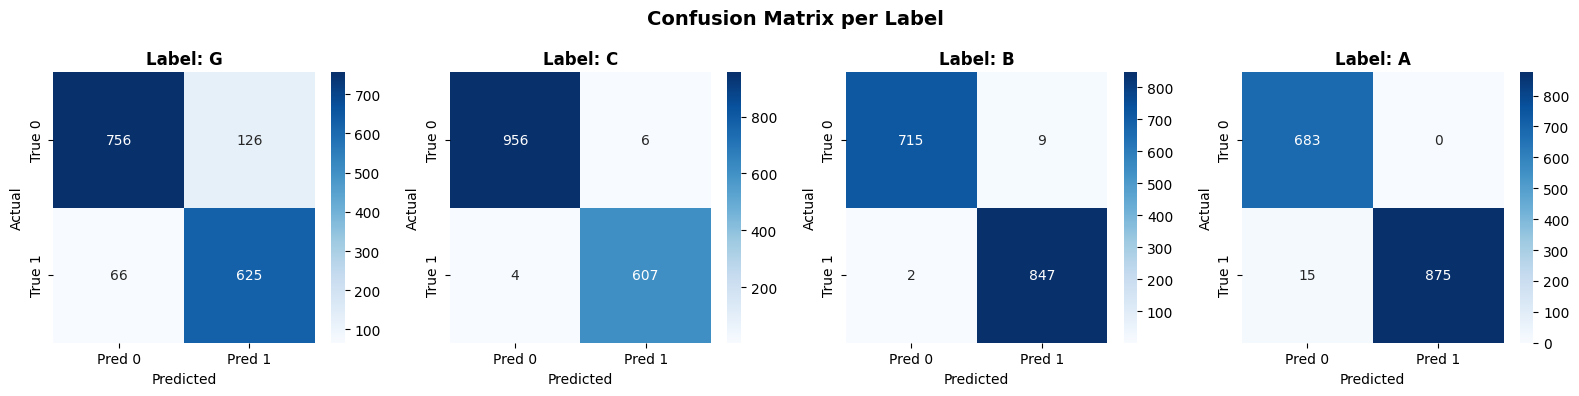


Label        TN     FP     FN     TP
────────────────────────────────
G           756    126     66    625
C           956      6      4    607
B           715      9      2    847
A           683      0     15    875


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

labels = ['G', 'C', 'B', 'A']

y_true = all_labels.numpy()
y_pred = all_preds.numpy()

# ── Multilabel Confusion Matrix ───────────────────────────────────────────────
mcm = multilabel_confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Confusion Matrix per Label', fontsize=14, fontweight='bold')

for i, (ax, cm, label) in enumerate(zip(axes, mcm, labels)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['True 0', 'True 1'])
    ax.set_title(f'Label: {label}', fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

# ── Print Numeric Summary ─────────────────────────────────────────────────────
print(f"\n{'Label':<8} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6}")
print("─" * 32)
for label, cm in zip(labels, mcm):
    tn, fp, fn, tp = cm.ravel()
    print(f"{label:<8} {tn:>6} {fp:>6} {fn:>6} {tp:>6}")